<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/%2BEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [2]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [3]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-2018-eng-stata-v20190303.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2018_Eng_Stata_v20190303.dta  
Archive:  latinobarometro/latinobarometro-2008-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2008_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2008_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2008_datos_eng_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2008_datos_esp_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2005-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2005_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2005_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2005_datos_esp_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2005_datos_eng_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2020-eng-stata-v1-0.zip
  inflating: latinobarometro/unzipped/Latino

In [4]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
}

}

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [6]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [7]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


In [8]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

In [9]:
#Eliminamos España
master = master[master['country'] != 724]

# Más EDA

In [10]:
import pandas as pd
import statsmodels.formula.api as smf

df = master.copy()


# Argentina
df["argentina"] = (df["country"] == 32).astype(int)

# Post reforma
df["post"] = (df["wave"] >= 2012).astype(int)

# Grupo tratado
df["young"] = df["age"].between(16,17).astype(int)

# Triple interacción
df["treatment"] = df["argentina"] * df["post"] * df["young"]

In [11]:
(
    master[master["age"] < 18]
    .groupby(["country", "wave"])
    .size()
    .unstack(fill_value=0)
)

wave,1995,1996,1997,1998,2001,2002,2003,2004,2005,2006,...,2010,2011,2013,2015,2016,2017,2018,2020,2023,2024
country,,,,,,,,,,,,,,,,,,,,,
76,122,106,111,57,66,66,70,74,68,69,...,61,58,59,59,53,59,50,49,43,43
170,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
188,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
222,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
320,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
484,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
558,0,39,0,0,37,79,66,77,72,96,...,80,97,66,70,85,39,65,78,0,0
591,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
600,1,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
br = master[master.country == 76]

br["age"].value_counts().sort_index().loc[14:20]

,count
age,
15.0,107
16.0,678
17.0,739
18.0,879
19.0,658
20.0,609


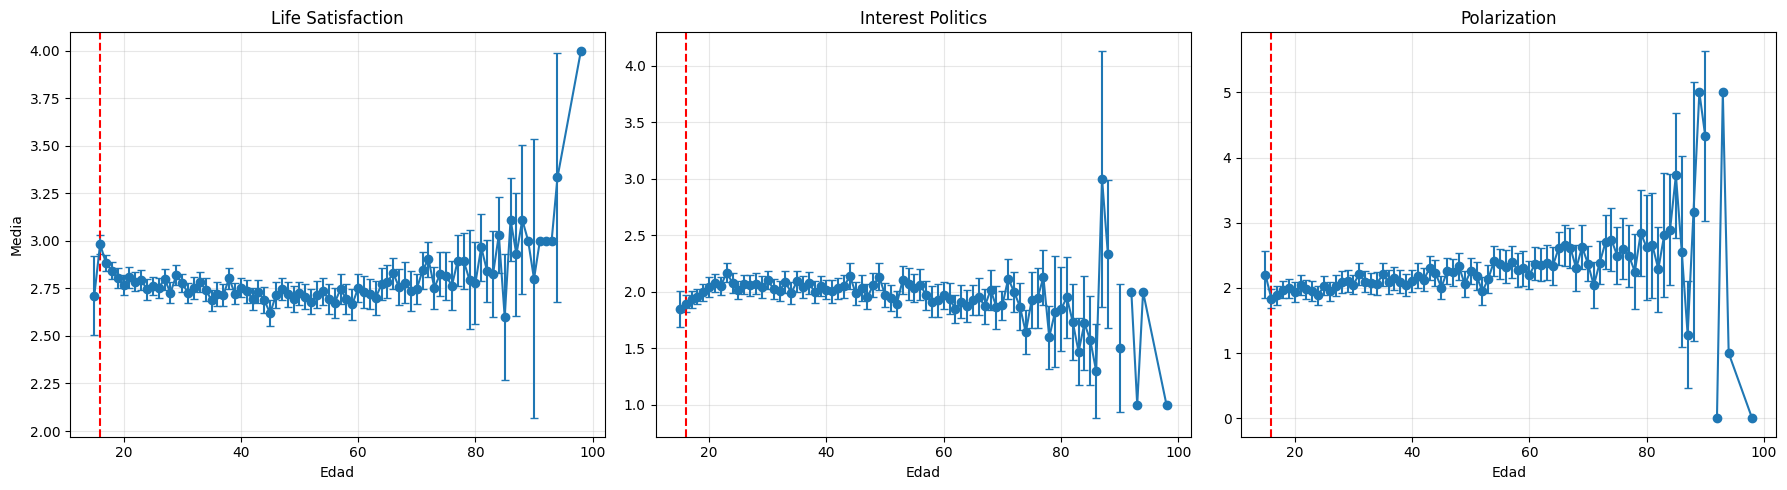

In [13]:
import numpy as np
import matplotlib.pyplot as plt

br = master[master["country"] == 76].copy()

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "polarization"
]

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharex=True)

for ax, var in zip(axes, vars_plot):

    stats = (
        br.groupby("age")[var]
          .agg(["mean","std","count"])
          .reset_index()
    )

    stats["se"] = stats["std"] / np.sqrt(stats["count"])
    stats["ci"] = 1.96 * stats["se"]

    ax.errorbar(
        stats["age"],
        stats["mean"],
        yerr=stats["ci"],
        fmt="o-",
        capsize=3
    )

    ax.axvline(16, color="red", linestyle="--")
    ax.set_title(var.replace("_"," ").title())
    ax.set_xlabel("Edad")
    ax.grid(alpha=.3)

axes[0].set_ylabel("Media")

plt.tight_layout()
plt.show()

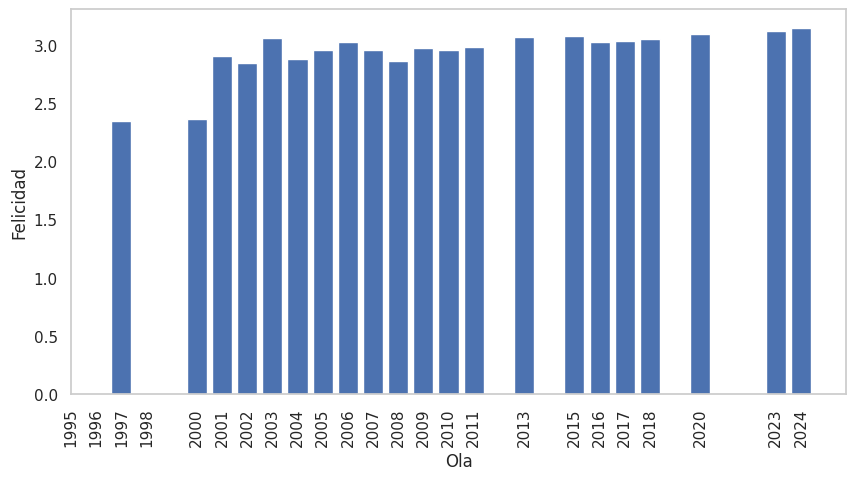

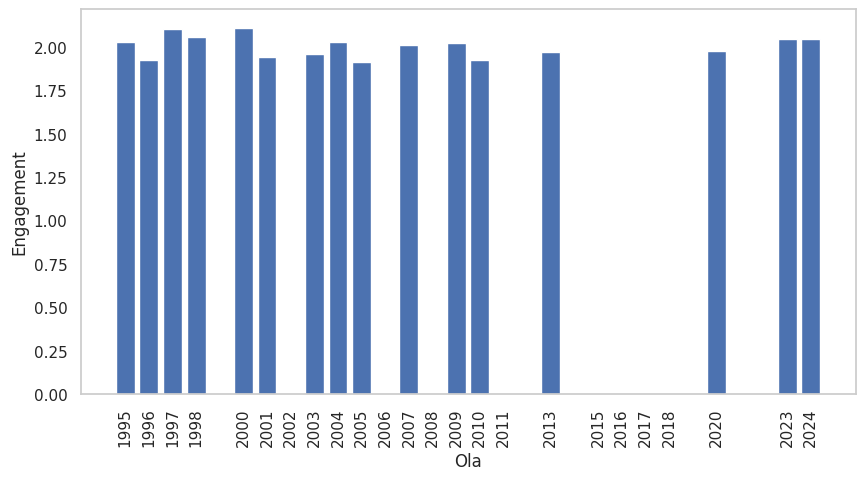

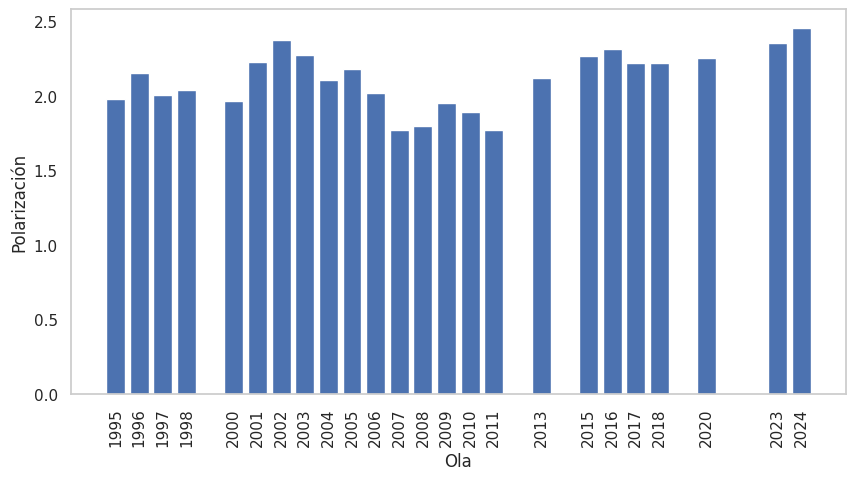

In [36]:

import matplotlib.pyplot as plt
import pandas as pd

# =========================
# preparar datos
# =========================

yearly = (
    master
    .groupby("wave")[
        [
            "life_satisfaction",
            "interest_politics",
            "left_right_distance"
        ]
    ]
    .mean()
    .reset_index()
)

yearly = yearly.rename(columns={
    "life_satisfaction": "felicidad",
    "interest_politics": "engagement",
    "left_right_distance": "polarization"
})

# ordenar por wave por seguridad
yearly = yearly.sort_values("wave")

waves = yearly["wave"]

# =========================
# felicidad
# =========================

plt.figure(figsize=(10,5))
plt.grid(False)
plt.bar(waves, yearly["felicidad"])

#plt.title("Felicidad promedio por ola")
plt.xlabel("Ola")
plt.ylabel("Felicidad")

plt.xticks(waves, rotation=90)

plt.show()

# =========================
# engagement político
# =========================

plt.figure(figsize=(10,5))
plt.grid(False)
plt.bar(waves, yearly["engagement"])

#plt.title("Interés en política por ola")
plt.xlabel("Ola")
plt.ylabel("Engagement")

plt.xticks(waves, rotation=90)

plt.show()

# =========================
# polarización
# =========================

plt.figure(figsize=(10,5))
plt.grid(False)
plt.bar(waves, yearly["polarization"])

#plt.title("Distancia ideológica al centro por ola")
plt.xlabel("Ola")
plt.ylabel("Polarización")

plt.xticks(waves, rotation=90)

plt.show()

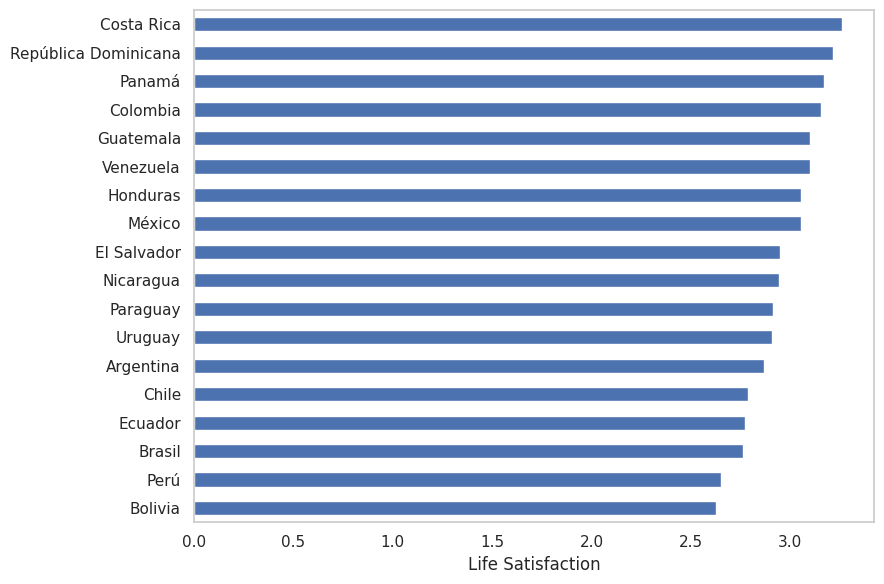

In [37]:
import matplotlib.pyplot as plt

country_map = {
    32: "Argentina",
    68: "Bolivia",
    76: "Brasil",
    152: "Chile",
    170: "Colombia",
    188: "Costa Rica",
    214: "República Dominicana",
    218: "Ecuador",
    222: "El Salvador",
    320: "Guatemala",
    340: "Honduras",
    484: "México",
    558: "Nicaragua",
    591: "Panamá",
    600: "Paraguay",
    604: "Perú",
    858: "Uruguay",
    862: "Venezuela"
}

# Variable a graficar
var = "life_satisfaction"

country_means = (
    master.groupby("country")[var]
    .mean()
    .rename(index=country_map)
    .sort_values()
)

plt.figure(figsize=(9,6))

country_means.plot(kind="barh")

plt.xlabel(var.replace("_", " ").title())
plt.ylabel("")
plt.grid(False)
#plt.title(f"Promedio de {var.replace('_',' ').title()} por país")

plt.tight_layout()
plt.show()

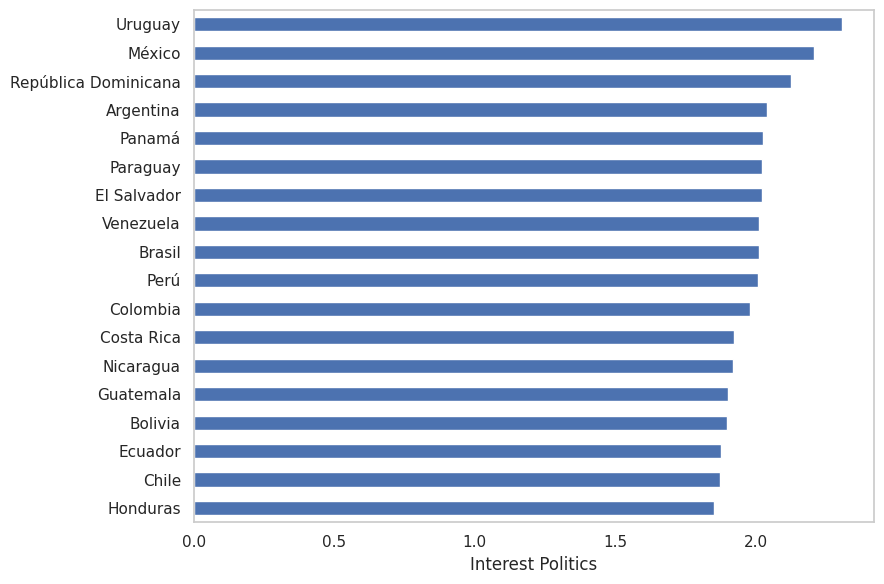

In [38]:
# Variable a graficar
var = "interest_politics"

country_means = (
    master.groupby("country")[var]
    .mean()
    .rename(index=country_map)
    .sort_values()
)

plt.figure(figsize=(9,6))

country_means.plot(kind="barh")

plt.xlabel(var.replace("_", " ").title())
plt.ylabel("")
plt.grid(False)
#plt.title(f"Promedio de {var.replace('_',' ').title()} por país")

plt.tight_layout()
plt.show()

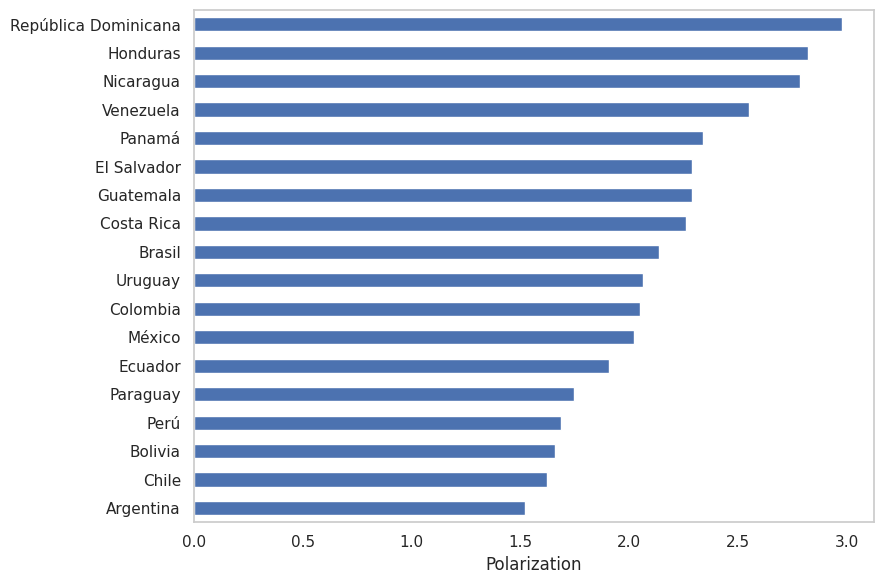

In [39]:
# Variable a graficar
var = "polarization"

country_means = (
    master.groupby("country")[var]
    .mean()
    .rename(index=country_map)
    .sort_values()
)

plt.figure(figsize=(9,6))

country_means.plot(kind="barh")

plt.xlabel(var.replace("_", " ").title())
plt.ylabel("")
plt.grid(False)
#plt.title(f"Promedio de {var.replace('_',' ').title()} por país")

plt.tight_layout()
plt.show()

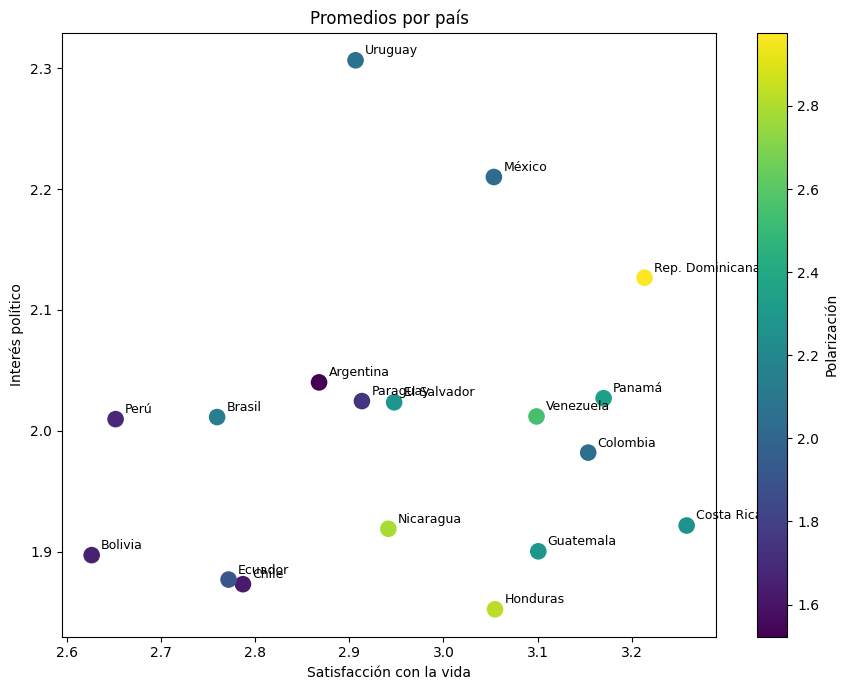

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


# Promedios por país
country = (
    master.groupby("country")[[
        "life_satisfaction",
        "interest_politics",
        "polarization"
    ]]
    .mean()
    .reset_index()
)

country["country_name"] = country["country"].map(country_map)

plt.figure(figsize=(9,7))

sc = plt.scatter(
    country["life_satisfaction"],
    country["interest_politics"],
    c=country["polarization"],
    s=120,
)

# Etiquetas
for _, row in country.iterrows():
    plt.text(
        row["life_satisfaction"] + 0.01,
        row["interest_politics"] + 0.005,
        row["country_name"],
        fontsize=9
    )

cbar = plt.colorbar(sc)
cbar.set_label("Polarización")

plt.xlabel("Satisfacción con la vida")
plt.ylabel("Interés político")
plt.title("Promedios por país")

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

wave_means = (
    master.groupby("wave")[[
        "life_satisfaction",
        "interest_politics",
        "polarization"
    ]]
    .mean()
    .dropna()
    .reset_index()
    .sort_values("wave")
)

wave_means

,wave,life_satisfaction,interest_politics,polarization
0,1997,2.351060,2.106340,2.009398
1,2000,2.365140,2.113045,1.964082
2,2001,2.905119,1.945218,2.227452
3,2003,3.066789,1.959148,2.272369
4,2004,2.880672,2.029540,2.109285
5,2005,2.957095,1.914768,2.183356
6,2007,2.960538,2.010697,1.775200
7,2009,2.975642,2.024488,1.953912
8,2010,2.959359,1.927404,1.894974
9,2013,3.072564,1.973018,2.120986


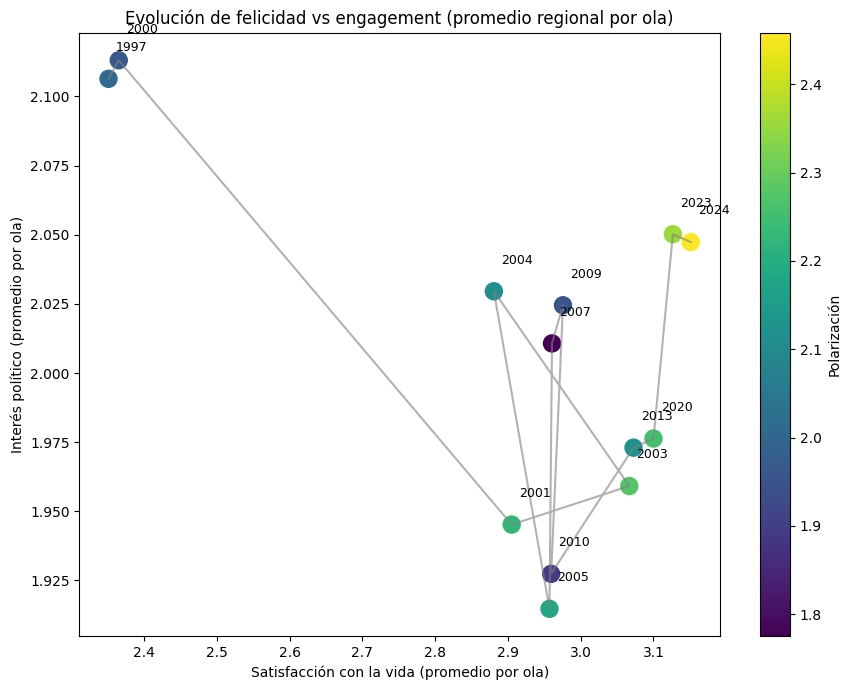

In [17]:
import matplotlib.pyplot as plt

df = wave_means.copy()

plt.figure(figsize=(9,7))

# scatter
sc = plt.scatter(
    df["life_satisfaction"],
    df["interest_politics"],
    c=df["polarization"],
    cmap="viridis",
    s=150
)

# línea conectando olas en orden temporal
plt.plot(
    df["life_satisfaction"].to_numpy(),
    df["interest_politics"].to_numpy(),
    color="gray",
    alpha=0.6
)

# etiquetas (año de ola)
for _, r in df.iterrows():
    plt.text(
        r["life_satisfaction"] + 0.01,
        r["interest_politics"] + 0.01,
        str(int(r["wave"])),
        fontsize=9
    )

cbar = plt.colorbar(sc)
cbar.set_label("Polarización")

plt.xlabel("Satisfacción con la vida (promedio por ola)")
plt.ylabel("Interés político (promedio por ola)")
plt.title("Evolución de felicidad vs engagement (promedio regional por ola)")

plt.tight_layout()
plt.show()

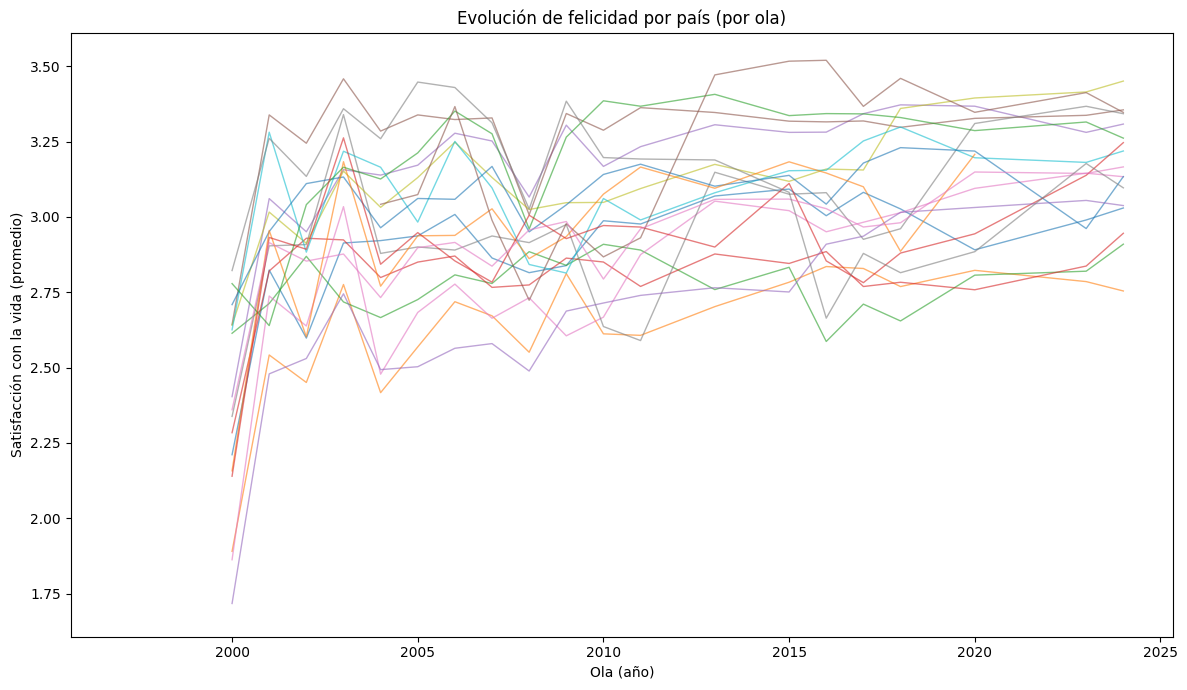

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

country_map = {
    32: "Argentina",
    68: "Bolivia",
    76: "Brasil",
    152: "Chile",
    170: "Colombia",
    188: "Costa Rica",
    214: "Rep. Dominicana",
    218: "Ecuador",
    222: "El Salvador",
    320: "Guatemala",
    340: "Honduras",
    484: "México",
    558: "Nicaragua",
    591: "Panamá",
    600: "Paraguay",
    604: "Perú",
    858: "Uruguay",
    862: "Venezuela"
}

# promedio por país-ola
df = (
    master
    .groupby(["country", "wave"])["life_satisfaction"]
    .mean()
    .reset_index()
    .sort_values(["country", "wave"])
)

df["country_name"] = df["country"].map(country_map)

plt.figure(figsize=(12, 7))

for c, g in df.groupby("country_name"):
    g = g.sort_values("wave")
    plt.plot(g["wave"], g["life_satisfaction"], alpha=0.6, linewidth=1)

plt.xlabel("Ola (año)")
plt.ylabel("Satisfacción con la vida (promedio)")
plt.title("Evolución de felicidad por país (por ola)")

plt.tight_layout()
plt.show()

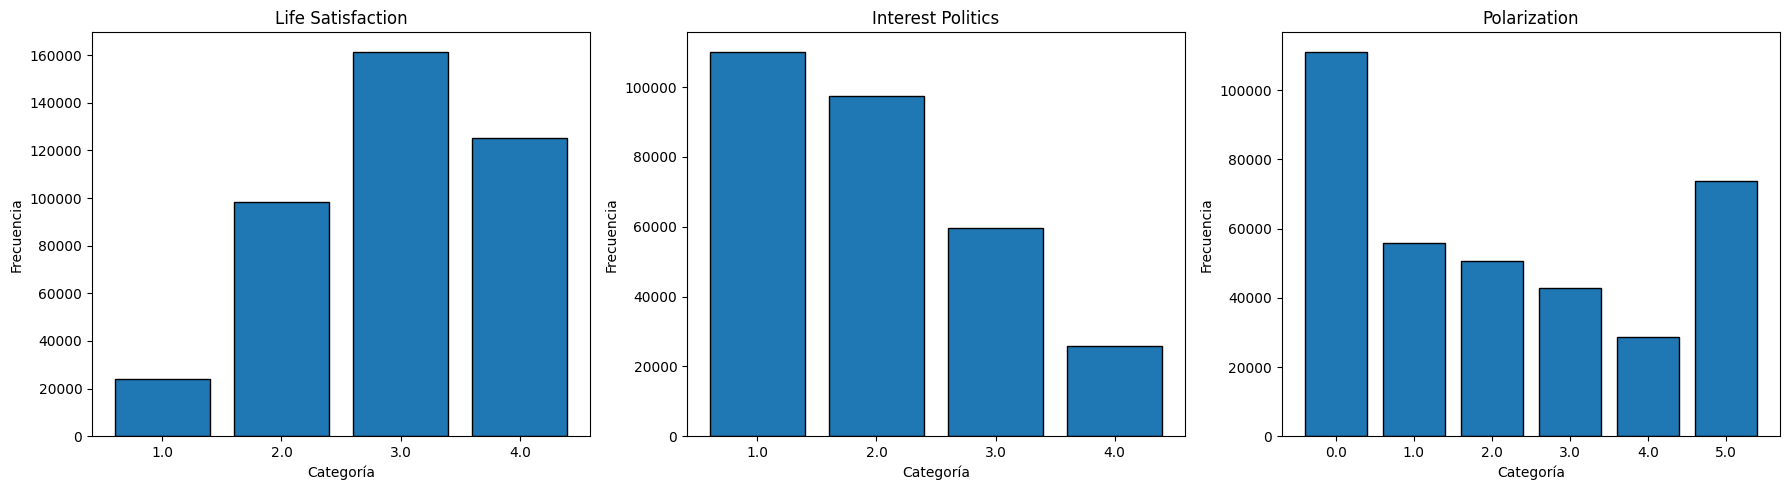

In [19]:
import matplotlib.pyplot as plt

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "polarization"
]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, var in zip(axes, vars_plot):

    counts = master[var].value_counts(dropna=True).sort_index()

    ax.bar(counts.index.astype(str), counts.values, edgecolor="black")

    ax.set_title(var.replace("_", " ").title())
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

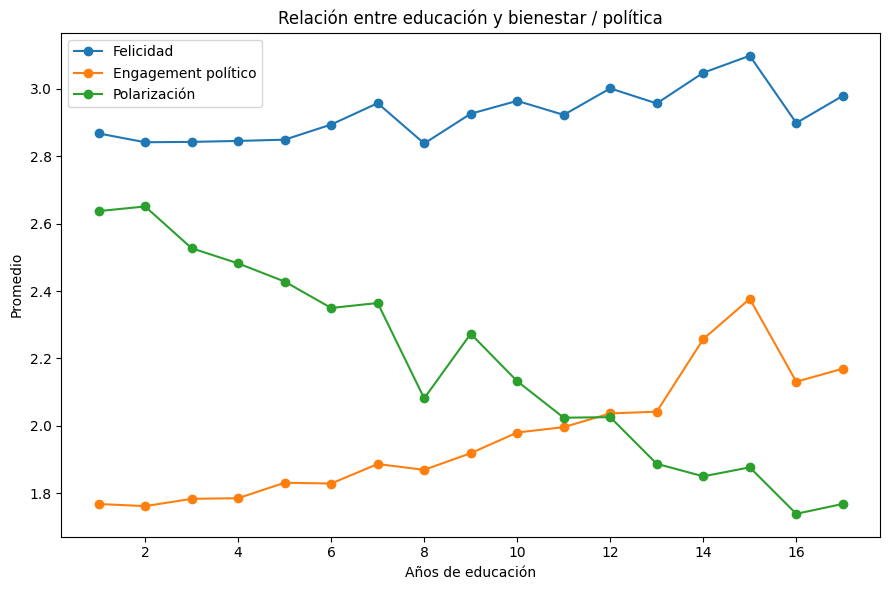

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = (
    master[master["education_num"] >= 1]
    .groupby("education_num")[[
        "life_satisfaction",
        "interest_politics",
        "polarization"
    ]]
    .mean()
    .reset_index()
    .sort_values("education_num")
)

plt.figure(figsize=(9,6))

plt.plot(df["education_num"], df["life_satisfaction"], marker="o", label="Felicidad")
plt.plot(df["education_num"], df["interest_politics"], marker="o", label="Engagement político")
plt.plot(df["education_num"], df["polarization"], marker="o", label="Polarización")

plt.xlabel("Años de educación")
plt.ylabel("Promedio")
plt.title("Relación entre educación y bienestar / política")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2474/4157458528.py:75: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(


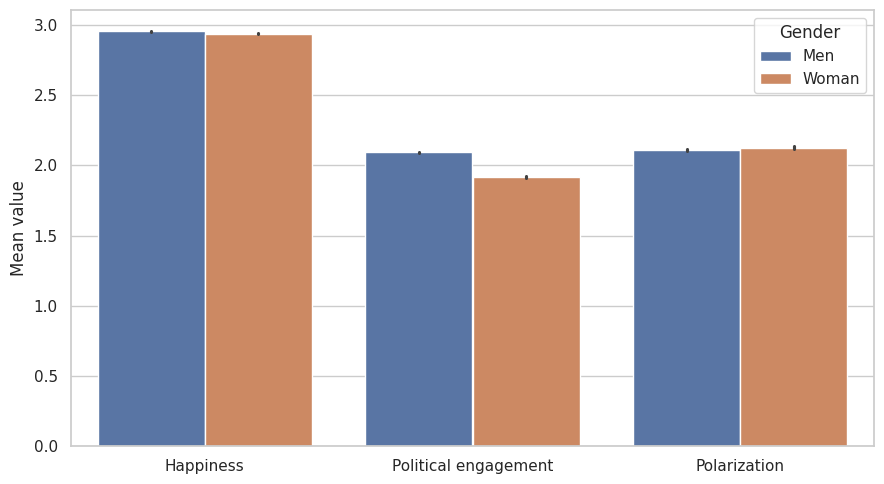

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# género
# ---------------------------------

gender_map = {
    1: "Men",
    0: "Woman"
}

# ---------------------------------
# elegir rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

df_plot["gender_label"] = (
    df_plot["sex"]
    .map(gender_map)
)

# ---------------------------------
# variables
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# formato largo
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="gender_label",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = (
    df_melt["variable"]
    .map(labels_map)
)

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="gender_label",
    errorbar=("ci", 95),
    palette=sns.color_palette("deep")
)

plt.xlabel("")
plt.ylabel("Mean value")

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [22]:
from pandas.io.stata import StataReader

file = "latinobarometro/unzipped/Latinobarometro_2018_Esp_Stata_v20190303.dta"

reader = StataReader(file)

value_labels = reader.value_labels()

df_tmp = pd.read_stata(file, convert_categoricals=False)

reader = StataReader(file)

value_labels = reader.value_labels()

# ver labels de la variable directamente
reader.value_labels().get("S23")

{np.int32(1): 'Casado/ Conviviente',
 np.int32(2): 'Soltero',
 np.int32(3): 'Separado/Divorciado/Viudo',
 np.int32(-1): 'No sabe/No responde'}

/tmp/ipykernel_2474/1595113528.py:82: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(


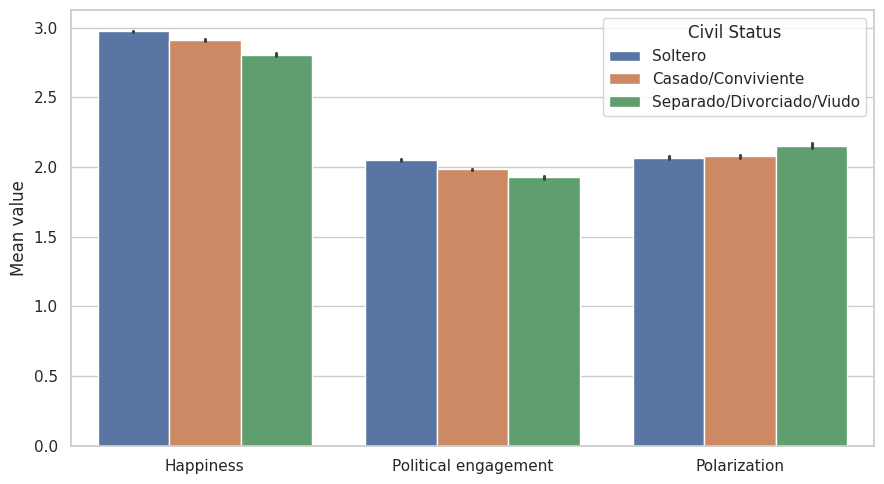

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# género
# ---------------------------------

civil_map = {
    1: "Casado/Conviviente",
    2: "Soltero",
    3: "Separado/Divorciado/Viudo"
}

# ---------------------------------
# elegir rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

df_plot["civil_label"] = (
    df_plot["civil_status"]
    .map(civil_map)
)

# ---------------------------------
# variables
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# formato largo
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="civil_label",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = (
    df_melt["variable"]
    .map(labels_map)
)

hue_order = [
    "Soltero",
    "Casado/Conviviente",
    "Separado/Divorciado/Viudo"
]

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="civil_label",
    hue_order=hue_order,
    errorbar=("ci", 95),
    palette=sns.color_palette("deep")
)

plt.xlabel("")
plt.ylabel("Mean value")

plt.legend(title="Civil Status")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2474/2544143906.py:75: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(


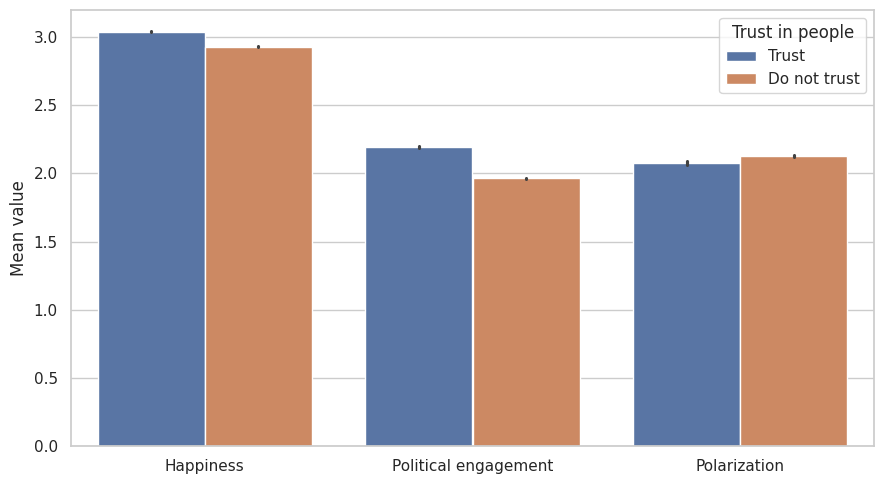

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# trust mapping (ajustable si tu coding difiere)
# ---------------------------------

trust_map = {
    1: "Trust",
    0: "Do not trust"
}

# ---------------------------------
# elegir rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

df_plot["trust_label"] = df_plot["trust_people"].map(trust_map)

# ---------------------------------
# variables
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# formato largo
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="trust_label",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = df_melt["variable"].map(labels_map)

# ---------------------------------
# orden explícito
# ---------------------------------

hue_order = ["Trust", "Do not trust"]

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="trust_label",
    hue_order=hue_order,
    errorbar=("ci", 95),
    palette=sns.color_palette("deep")
)

plt.xlabel("")
plt.ylabel("Mean value")
plt.legend(title="Trust in people")

plt.tight_layout()
plt.show()

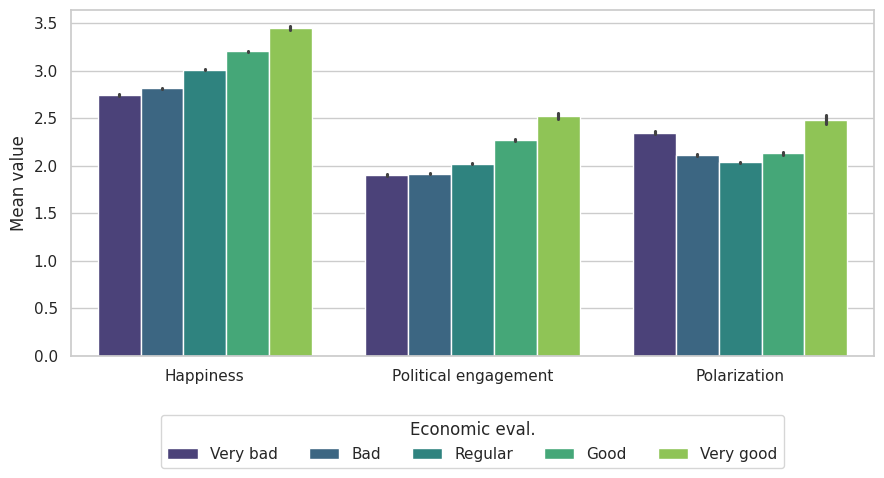

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# mapping (ajustable según coding exacto)
# típico Latinobarómetro:
# 1 = Muy buena
# 2 = Buena
# 3 = Regular
# 4 = Mala
# 5 = Muy mala
# ---------------------------------

econ_map = {
    1: "Very bad",
    2: "Bad",
    3: "Regular",
    4: "Good",
    5: "Very good"
}

econ_order = [
    "Very bad",
    "Bad",
    "Regular",
    "Good",
    "Very good"
]

# ---------------------------------
# rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

df_plot["econ_label"] = df_plot["econ_country"].map(econ_map)

# ---------------------------------
# variables outcome
# ---------------------------------

vars_plot = [
    "life_satisfaction",
    "interest_politics",
    "left_right_distance"
]

labels_map = {
    "life_satisfaction": "Happiness",
    "interest_politics": "Political engagement",
    "left_right_distance": "Polarization"
}

# ---------------------------------
# long format
# ---------------------------------

df_melt = df_plot.melt(
    id_vars="econ_label",
    value_vars=vars_plot,
    var_name="variable",
    value_name="value"
)

df_melt["variable"] = df_melt["variable"].map(labels_map)

# ---------------------------------
# plot
# ---------------------------------

plt.figure(figsize=(9,5))

sns.barplot(
    data=df_melt,
    x="variable",
    y="value",
    hue="econ_label",
    hue_order=econ_order,
    errorbar=("ci", 95),
    palette=sns.color_palette("viridis", len(econ_order))
)

plt.xlabel("")
plt.ylabel("Mean value")
plt.legend(
    title="Economic eval.",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=5
)

plt.tight_layout()
plt.show()

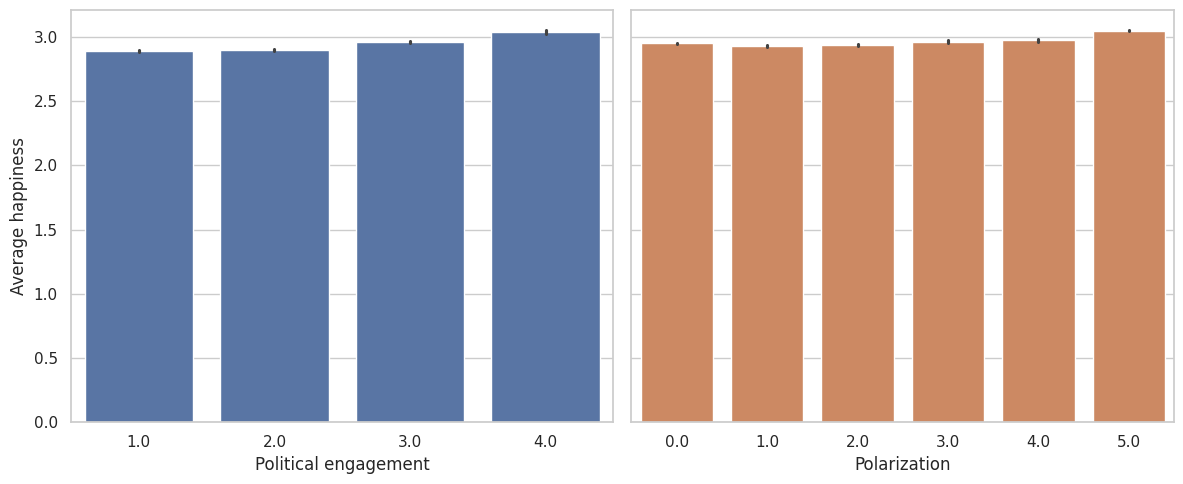

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------
# estilo
# ---------------------------------

sns.set_theme(style="whitegrid")

# ---------------------------------
# elegir rango de años
# ---------------------------------

start_year = 1995
end_year = 2024

df_plot = master[
    (master["wave"] >= start_year) &
    (master["wave"] <= end_year)
].copy()

# ---------------------------------
# figura
# ---------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Political engagement
sns.barplot(
    data=df_plot,
    x="interest_politics",
    y="life_satisfaction",
    errorbar=("ci", 95),
    color=sns.color_palette("deep")[0],
    ax=axes[0]
)

#axes[0].set_title("Political engagement")
axes[0].set_xlabel("Political engagement")
axes[0].set_ylabel("Average happiness")

# Polarization
sns.barplot(
    data=df_plot,
    x="left_right_distance",
    y="life_satisfaction",
    errorbar=("ci", 95),
    color=sns.color_palette("deep")[1],
    ax=axes[1]
)

#axes[1].set_title("Polarization")
axes[1].set_xlabel("Polarization")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

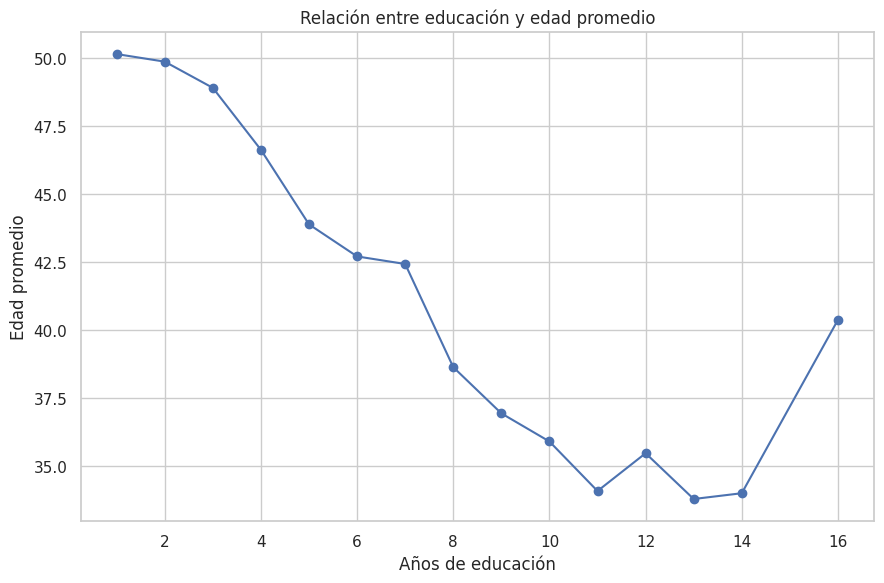

In [40]:
# La relación entre educación y la edad promedio es negativa pero podría deberse a la expansión de la educación en el tiempo.

import pandas as pd
import matplotlib.pyplot as plt

df_age = (
    master[master["education"] >= 1]
    .groupby("education")["age"]
    .mean()
    .reset_index()
    .sort_values("education")
)

plt.figure(figsize=(9,6))

plt.plot(df_age["education"], df_age["age"], marker="o")

plt.xlabel("Años de educación")
plt.ylabel("Edad promedio")
plt.title("Relación entre educación y edad promedio")

plt.tight_layout()
plt.show()